# 9.10.1 LLM Production Deployment & Optimization

---

## Table of Contents

1. [RAG Latency Optimization Guide](#-rag-latency-optimization-guide)
2. [Scaling, Latency, and Throughput Optimization](#-scaling-latency-and-throughput-optimization-in-llm-systems)
3. [PagedAttention, vLLM & Inference Optimization](#%EF%B8%8F-inference-optimization-techniques-in-llms)
4. [Token Batching in vLLM](#-token-batching-used-in-vllm-explained)
5. [Production Deployment Checklist](#-production-deployment-checklist)
6. [Serving Frameworks Comparison](#-serving-frameworks-comparison)
7. [Cost Optimization Guide](#-cost-optimization-guide-for-llm-serving)
8. [Monitoring & Observability for LLM Serving](#-monitoring--observability-for-llm-serving)
9. [A/B Testing LLM Deployments](#-ab-testing-llm-deployments)
10. [Top 10 LLM Production Interview Q&A](#-top-10-llm-production-interview-qa)
11. [References](#-references)

---

> **Cross-Reference:** For detailed inference optimization techniques (16 methods including quantization, pruning, distillation, FlashAttention, speculative decoding, KV cache optimization, and more), see **notebook 9.9.10 - LLM Inference Optimization**. This notebook focuses specifically on **production deployment, serving infrastructure, cost optimization, and operational excellence**.


> 🔍 **Optimizing Latency in RAG (Retrieval-Augmented Generation) Systems**

---

# ⚡ RAG Latency Optimization Guide

Latency in RAG systems arises from:
1. **Document Retrieval**
2. **Context Construction**
3. **LLM Generation**

Below, we outline **end-to-end strategies** to minimize delay at each stage.

---

## 🔹 1. Retrieval Latency Optimization

| Technique                        | Purpose                                           | How it Helps                             |
|----------------------------------|---------------------------------------------------|-------------------------------------------|
| **In-Memory Vector Stores**      | Replace disk-based search (e.g., FAISS on RAM)   | Faster retrieval (~ms vs ~100ms)          |
| **Smaller Embeddings**           | Use lower-dimension models (MiniLM, BGE-small)   | Faster encoding, smaller index            |
| **Asynchronous Retrieval**       | Use async APIs + event loop                      | Parallelizes queries to vector store      |
| **Query Caching**                | Store popular queries + results                  | Zero-latency for repeated questions       |
| **Approximate Nearest Neighbor (ANN)** | Use HNSW or IVF instead of exact search     | Reduces retrieval time at slight recall cost |
| **Query Pruning / Deduplication**| Clean/optimize queries before retrieval          | Reduces redundancy, speeds up index lookup |

---

## 🔹 2. Context Construction Optimization

| Strategy                        | Description                                      | Benefit                                   |
|----------------------------------|--------------------------------------------------|-------------------------------------------|
| **Smart Chunking**              | Fixed-size + overlap or sentence-aware chunks    | Improves relevance & reduces token waste  |
| **Document Re-ranking**         | Use lightweight reranker (e.g., mini-BERT)       | Selects most relevant chunks quickly      |
| **Dynamic Context Trimming**    | Drop low-relevance or long tail chunks           | Keeps LLM input minimal                   |
| **Token Budgeting**             | Prioritize high-value docs to fit token limit    | Reduces prefill latency                   |

---

## 🔹 3. Generation Latency Optimization

| Method                         | Description                                       | Use Case                                  |
|--------------------------------|--------------------------------------------------|-------------------------------------------|
| **Token Streaming**            | Serve tokens as generated (via SSE/WebSocket)    | Lowers perceived latency (TTFT↓)          |
| **vLLM or Triton Inference**   | High-throughput server with `PagedAttention`     | Efficient batch/streaming gen             |
| **Prompt Pruning**             | Remove irrelevant prompt history/context         | Shrinks input tokens → faster decode      |
| **LoRA / Distilled LLMs**      | Smaller fine-tuned models                        | Reduce generation time dramatically       |
| **Speculative Decoding**       | Use draft model to speed up generation           | Predicts next tokens, verifies with main  |
| **Beam size = 1**              | Avoid beam search unless necessary               | Faster generation                         |

---

## 🔹 4. System-Level Optimizations

| Optimization                  | Description                                       | Benefit                                   |
|-------------------------------|---------------------------------------------------|-------------------------------------------|
| **Async Backend**            | Async FastAPI / Flask / Node.js with task queues | Avoids blocking calls                     |
| **Batching** (Retrieval + Gen)| Combine requests (via queue or scheduler)        | Improves GPU throughput                   |
| **Model Warm Pooling**       | Keep LLM weights warm in memory                  | Avoids cold start on first gen            |
| **Parallel RAG Pipelines**   | Retrieval + generation run in parallel threads   | Latency hidden via concurrency            |
| **Edge Retrieval**           | Serve embeddings/vector DB at edge or CDN        | Minimize network latency                  |

---

## 🧠 Bonus: Advanced Tricks

| Trick                          | Description                                       |
|--------------------------------|--------------------------------------------------|
| **HyDE (Hypothetical Q&A)**   | Generate query variants with LLM for retrieval   |
| **Retrieval Fusion**          | Combine top-k from multiple retrievers           |
| **RAG-Fusion**                | Use answers from multiple retrieved contexts     |
| **Hybrid Search**             | Combine BM25 + dense vector (re-rank or fuse)    |

---

## ✅ Summary (One-liner for Interview)

> “RAG latency can be optimized by combining fast retrieval (ANN + cache), minimal context construction (rerank + trim), and fast generation (streaming + vLLM + prompt pruning).”

---

## 🧵 Takeaway (2-liner)

- **Latency in RAG** isn’t just about the model — it’s about optimizing every step from **retrieval to response**.
- Use **streaming, smart context trimming, async APIs, and inference engines like vLLM** to deliver low-latency experiences at scale.

---





# 🧠 Scaling, Latency, and Throughput Optimization in LLM Systems

---

## 🚀 1. Key Concepts

| Term         | Description                                                                 |
|--------------|-----------------------------------------------------------------------------|
| **Latency**  | Time taken from request to first token (response initiation)               |
| **Throughput**| Number of tokens or requests served per second                            |
| **Scaling**  | Ability to handle increasing users/requests while maintaining performance  |

---

## ⚙️ 2. Types of Scaling

| Type        | Technique                                                              | Use Case |
|-------------|-----------------------------------------------------------------------|----------|
| **Vertical**| Bigger GPU, more VRAM (e.g., A100 → H100)                              | Single model on single node |
| **Horizontal** | Multiple nodes, model sharding, request batching                     | Distributed inference |
| **Elastic** | Auto-scaling based on load (Kubernetes, SageMaker, Ray Serve)         | On-demand load spikes |

---

## 📉 3. Latency Bottlenecks & Solutions

### 🔸 A. **Cold Start**
- **Issue**: Time to load weights into memory.
- **Solution**: Use **vLLM**, **model warm pooling**, or keep **inference server always warm**.

### 🔸 B. **Token Generation Speed**
- **Issue**: Auto-regressive generation is inherently slow.
- **Solution**:
  - Use **FlashAttention**, **Speculative Decoding**, or **KV Caching**
  - Use **compiled models** (ONNX, TensorRT, vLLM with PagedAttention)

### 🔸 C. **Prompt Processing**
- **Issue**: Large prompt → slow prefill phase.
- **Solution**:
  - **Prompt compression** (summarization, retrieval)
  - Limit prompt length (`max_input_tokens`)
  - Use **retrieval-augmented generation (RAG)** with deduplication

---

## 🧵 4. Improving Throughput (High Concurrency)

### 🔹 A. **Batching Inference Requests**
- Merge multiple user requests into a single forward pass
- Use **vLLM** or **DeepSpeed-Inference** for token-level batching

### 🔹 B. **Async API Handling**
- Use **FastAPI + asyncio** or **Node.js** to handle thousands of concurrent users
- Integrate with **queue systems** (Kafka, RabbitMQ, Celery)

### 🔹 C. **Streaming Output**
- Stream tokens as they are generated using:
  - `Server-Sent Events (SSE)`
  - `WebSockets`
- Reduces *time-to-first-token (TTFT)*

---

## 💾 5. Memory Optimization

| Technique                    | Description                                                     |
|-----------------------------|-----------------------------------------------------------------|
| **Quantization**            | Use INT8 / FP4 with bitsandbytes, GGUF, GPTQ                    |
| **KV Cache Offloading**     | Move key-value cache to CPU or lower precision                  |
| **LoRA Adapters**           | Keep base model frozen; load only tiny fine-tuned weights       |
| **PagedAttention** (vLLM)   | Manages KV cache with virtual memory paging                     |
| **Model Parallelism**       | Split model layers across GPUs (via DeepSpeed or Megatron)      |

---

## 📡 6. Load Balancing & Multi-Instance Serving

- Use **load balancers** (NGINX, Traefik) to route requests
- Deploy **multiple model replicas** using **K8s + autoscaling**
- Use **Ray Serve** or **Triton Inference Server** for efficient routing

---

## 🧠 7. Architecture for Scalable LLM Inference

```plaintext
                ┌────────────────────────┐
                │      Client / UI       │
                └──────────┬─────────────┘
                           ▼
            ┌─────────────────────────────┐
            │   Async API Gateway (FastAPI) │
            └──────────┬────────────────────┘
                       ▼
        ┌────────────────────────────────────────┐
        │   Task Queue (Kafka / Celery / RedisQ) │
        └──────────┬─────────────────────────────┘
                   ▼
┌───────────────────────────────────────────────┐
│ Model Inference Workers (vLLM / DeepSpeed)    │
│ - Batching                                     │
│ - Streaming                                    │
│ - Quantized or LoRA models                    │
└───────────────────────────────────────────────┘
                   │
                   ▼
        ┌─────────────────────────────┐
        │ Vector DB / RAG Retriever   │
        └─────────────────────────────┘
```

---

## 🧪 8. Optional Enhancements

| Feature                    | Benefit                                               |
|---------------------------|--------------------------------------------------------|
| **Speculative Decoding**  | Fast token guessing using a small draft model          |
| **Mixture of Experts (MoE)** | Sparse activation for lower compute per token         |
| **Distilled / Quantized Models** | Smaller, faster models with minimal quality drop   |
| **Streaming-aware Prompt Truncation** | Drop irrelevant history for fast response      |

---

## ✅ Summary (One-liner for Interview)

> "To scale LLMs efficiently, optimize memory (KV caching, quantization), handle concurrency with async + batching (vLLM), and reduce latency with streaming, prompt pruning, and model warm-starting."

---

## 🧵 Takeaway (2-liner)

- Efficient GenAI systems balance **latency, throughput, and cost**.
- Use **vLLM, batching, streaming, and quantization** to serve 1000+ users smoothly.




> ✅ `PagedAttention`,  
> ✅ `Virtual Memory Mapping` in vLLM,  
> ✅ `vLLM` vs `DeepSpeed-Inference`,  
> ✅ `Batching Inference` for LLMs.


---

# ⚙️ Inference Optimization Techniques in LLMs

---

## 🔹 1. PagedAttention (vLLM)

### 🔸 Problem It Solves:
Traditional LLMs allocate **static memory** for each input’s **KV cache** (Key-Value cache from self-attention). This leads to:
- **Memory fragmentation**
- **Low GPU utilization**
- **Frequent OOM (Out-of-Memory)** on long or multiple sequences

---

### 🔸 Concept:

`PagedAttention` introduces **virtual memory paging** (like OS paging) to manage **KV cache** in LLMs efficiently.

**Instead of pre-allocating large blocks**, it:
- Splits memory into **fixed-size pages** (like 128 KB)
- Tracks tokens per request and their memory via **page tables**
- Allocates and reuses pages **on-demand**, like `malloc` for attention

---

### 🔍 Example:

Suppose user A has a short prompt (10 tokens) and user B has a 1K prompt.
- Old methods: allocate KV cache for **max context length** (wasteful)
- `PagedAttention`: allocates **only as many pages** as needed per user

---

### ✅ Benefits:

| Feature                | Impact                                        |
|------------------------|-----------------------------------------------|
| Fine-grained paging    | Less memory waste                             |
| KV sharing & reuse     | Higher throughput                             |
| Dynamic allocation     | Better concurrency handling                   |
| Supports long context  | 16K–128K tokens with lower memory overhead    |

---

## 🔹 2. Virtual Memory Mapping (in vLLM)

### 📌 Core Idea:

Like a modern OS, **vLLM uses a virtual memory system** to map:
- Input sequences → memory pages
- Attention keys/values → virtual memory space

This enables:
- **Elastic context handling** (no hard truncation)
- **On-the-fly attention updates**
- **Multiple sequences sharing attention compute**

---

### 📘 Analogy:
- Think of **virtual memory** like a hotel with dynamic rooms.
- Each request gets pages (rooms) only when needed.
- Freed-up pages are **reused** for new requests.

---

## 🔹 3. vLLM vs DeepSpeed-Inference

| Feature                 | **vLLM**                                    | **DeepSpeed-Inference**                       |
|-------------------------|---------------------------------------------|-----------------------------------------------|
| Core Engine             | Custom C++ engine with `PagedAttention`     | Optimized PyTorch-based inference             |
| Memory Efficiency       | Best-in-class KV cache reuse                | Good (depends on tensor/activation offloading)|
| Streaming Support       | ✅ Yes                                      | ✅ Yes                                         |
| Batching                | Token-level batching                        | Request-level batching                        |
| Quantization Support    | GGUF, INT4, GPTQ models                     | Supports FP16, INT8, W8A8                     |
| Model Deployment        | vLLM server (FastAPI + engine)              | Hugging Face Transformers / Triton            |
| Multi-GPU Support       | ❌ (currently single GPU)                    | ✅ (via DeepSpeed ZeRO)                        |

---

## 🔹 4. Batching Inference for LLMs

### ⚡ Why Batch?
- Forward pass in Transformers is matrix-heavy → better GPU utilization when done in **batch**
- Avoids GPU idle time
- Increases **tokens/sec** → better throughput

---

### 🔸 Types of Batching

| Type                  | Description                                                                 |
|-----------------------|-----------------------------------------------------------------------------|
| **Request Batching**  | Combine multiple user inputs into a single batch                           |
| **Token Batching**    | Interleave different users’ token generations per step (used by vLLM)      |
| **Dynamic Batching**  | Add requests to batch queue until latency threshold met                    |

---

### 🧠 Example:
```python
# Instead of generating tokens one by one:
[user1] --> "Hello, how are"
[user2] --> "What's the weather"

# Batch their next token generation:
model.generate(["Hello, how are", "What's the weather"])
```

---

## 📈 Summary Table

| Component           | Purpose                             | Optimized By            |
|---------------------|--------------------------------------|--------------------------|
| **PagedAttention**  | Sparse dynamic KV cache allocation  | vLLM                     |
| **Virtual Memory**  | Efficient memory paging & reuse     | vLLM runtime             |
| **Batching**        | High GPU utilization                | vLLM / DeepSpeed         |
| **vLLM**            | Throughput & latency optimization   | PagedAttention, batching |
| **DeepSpeed-Inference** | Multi-GPU inference + quantization | ZeRO + Triton backend     |

---

## ✅ Interview Summary (One-liner)
> “PagedAttention in vLLM uses virtual memory paging for efficient KV cache reuse, enabling token-level batching, high throughput, and low latency in LLM inference.”

---

## 🧵 Takeaway (2-liner)
- **vLLM with PagedAttention** and **virtual memory mapping** brings OS-level memory efficiency to LLMs.
- Combine that with **token batching** and streaming to scale low-latency GenAI apps to 1000s of users.

---




---

# 🔄 Token Batching (used in vLLM): Explained

---

## ✅ What Is Token Batching?

> **Token Batching** = Interleaving **multiple users' generation steps** token-by-token in a **single forward pass**, rather than completing one user’s request before starting the next.

---

## 💥 Why It Matters

Traditional inference runs like this:

```text
User A: generate → token_1 → token_2 → ... → token_N
(then)
User B: generate → token_1 → token_2 → ... → token_M
```

⛔ **Problem**: Wastes GPU time. Long wait for user B. Each forward pass processes only one sequence’s token.

---

### ✅ Token Batching Instead:

```text
User A: token_1 → token_2 → ...
User B: token_1 → token_2 → ...
(All tokens generated in one batched forward pass per step)
```

💡 Think of it like:
> Multiple people writing one letter at a time in round-robin, instead of finishing one entire letter before starting the next.

---

## ⚙️ How It Works (Under the Hood)

### 🔁 Process in `vLLM` Inference Engine:

1. **Prefill Phase**:
   - First tokens from multiple users are preprocessed together (batched)
   - KV cache initialized using `PagedAttention`

2. **Decode Phase (Token Batching)**:
   - All users waiting for **next token** are **batched together**
   - A **single forward pass** generates *next tokens* for all active users
   - This continues **token-by-token**, round-robin style

3. **Scheduler**:
   - Built-in **round-robin scheduler** assigns which users’ tokens to process per step
   - Manages context switching, KV access, and output buffering efficiently

---

## 💡 Example

Let’s say 3 users are interacting:

| Step | Input                 | Batched Tokens for Model |
|------|-----------------------|---------------------------|
| 1    | ["Hello", "What", "I"]| → ["Hello", "What", "I"] |
| 2    | ["Hello there", "What is", "I am"]| → ["there", "is", "am"] |
| 3    | ["Hello there friend", "What is your", "I am fine"]| → ["friend", "your", "fine"] |

Instead of running 3x sequential forward passes, **vLLM batches the 3 inputs per token step**, saving massive GPU time.
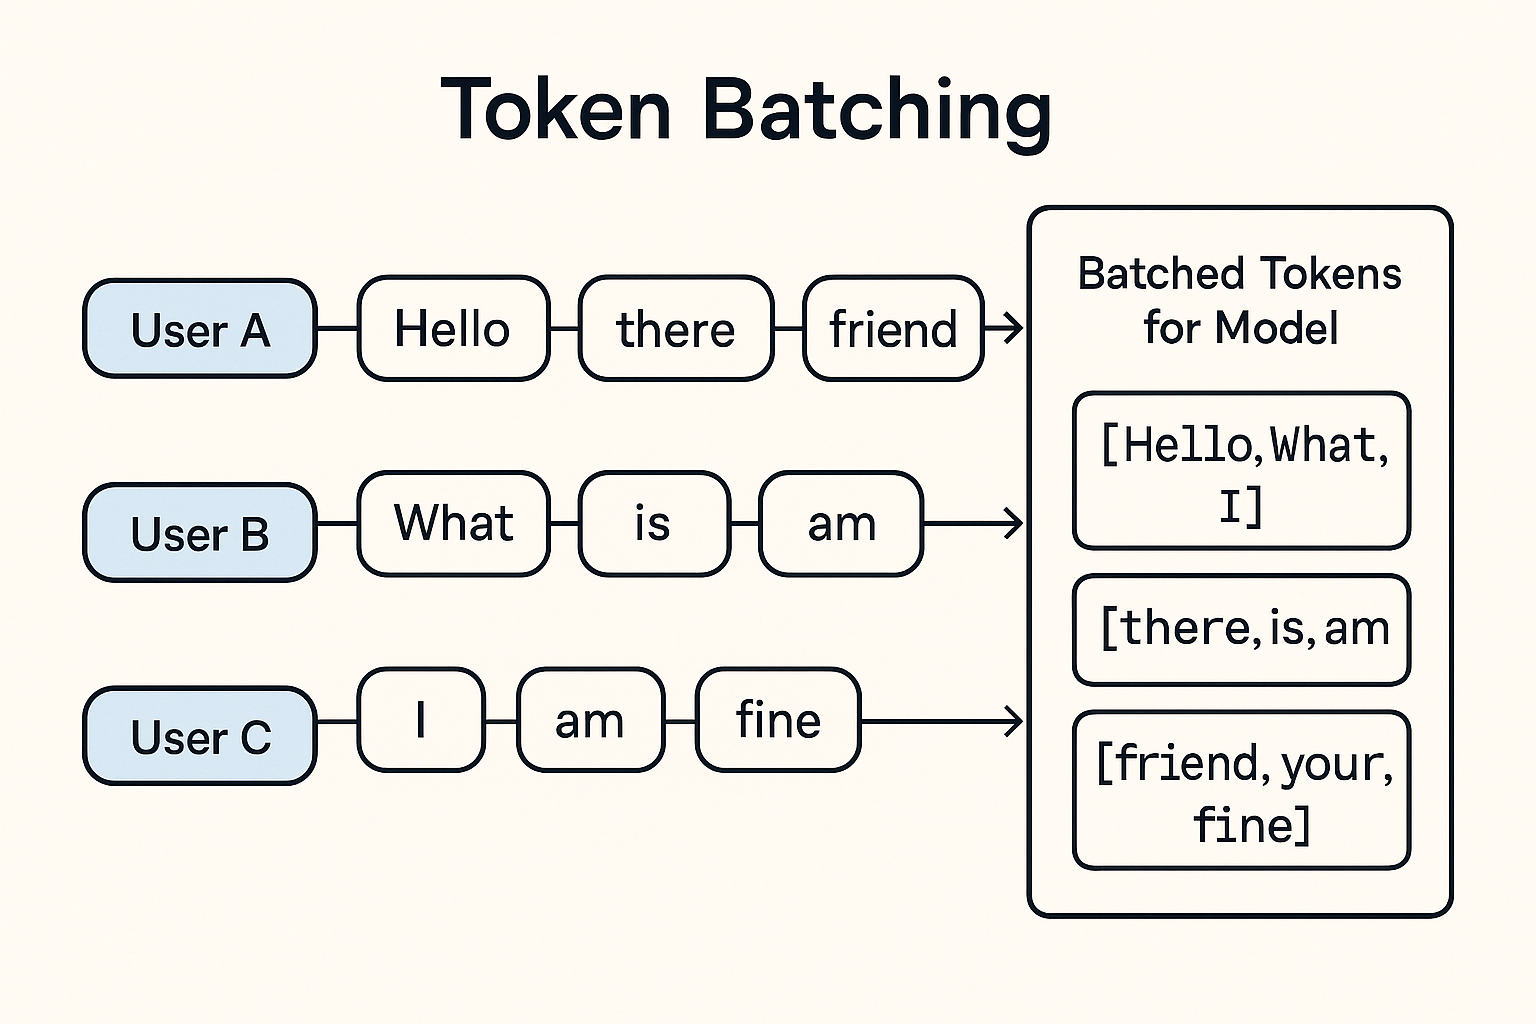
---

## 🛠 Where It’s Implemented

### ✅ vLLM Engine:
- Token batching is implemented in:
  - `vllm/engine/scheduler.py` → round-robin scheduler
  - `vllm/engine/model_executor.py` → merges token requests per step
  - Uses `PagedAttention` to efficiently access KV cache for each token and user

### ✅ APIs:
- `vLLM` provides a FastAPI interface where users send generation requests
- These requests are queued and token-batched behind the scenes before hitting the model

---

## 🧠 Token vs Request Batching — Key Difference

| Feature              | Token Batching (vLLM)                        | Request Batching (Standard)            |
|----------------------|----------------------------------------------|----------------------------------------|
| Batch Timing         | Token-by-token interleaving                 | Per full request                       |
| Efficiency           | Very high (GPU is always busy)              | Moderate (some idle time)              |
| Best For             | Long-running chats, multiple users          | Short, parallel completions            |
| Implementation       | Complex KV cache & scheduler needed         | Simpler                                |

---

## ✅ Summary (One-liner for Interview)

> “Token batching in vLLM allows multiple users’ next tokens to be generated in a single forward pass by interleaving decoding steps, maximizing GPU utilization and throughput.”

---

## 🧵 Takeaway (2-liner)

- **vLLM token batching** dramatically improves inference speed by batching token-level generations across users.
- It’s powered by a custom **scheduler** and **paged KV cache** for dynamic, concurrent decoding.



---

# 5. Production Deployment Checklist

> A structured, phase-by-phase checklist for taking an LLM from prototype to production.

---

## Phase 1: Model Selection & Preparation

| Step | Details | Key Questions |
|------|---------|---------------|
| **Choose model size** | Balance quality vs. latency vs. cost | Do you need 70B or will 7B-13B suffice? |
| **Evaluate open vs. closed** | GPT-4o/Claude vs. Llama/Mistral/Qwen | Data privacy? Vendor lock-in tolerance? |
| **Quantize if needed** | GPTQ, AWQ, GGUF (4-bit, 8-bit) | Acceptable quality degradation threshold? |
| **Fine-tune or use LoRA** | Task-specific adaptation | Is prompt engineering sufficient or do you need fine-tuning? |
| **Benchmark on your data** | Evaluate on real production queries | Use held-out test set with domain-specific metrics |

---

## Phase 2: Hardware Sizing & Infrastructure

| Step | Details | Guidance |
|------|---------|----------|
| **Estimate GPU memory** | Model params x bytes + KV cache + overhead | 7B FP16 ~ 14GB, 70B FP16 ~ 140GB |
| **Choose GPU type** | A10G (budget), A100 (balanced), H100 (performance) | Match to latency SLA and throughput needs |
| **Plan for multi-GPU** | Tensor parallelism for large models | 70B+ models typically need 2-4 GPUs |
| **Set up auto-scaling** | K8s HPA, AWS SageMaker, GCP Vertex AI | Define scale-up triggers (queue depth, GPU util, latency) |
| **Configure networking** | Low-latency internal networking, CDN for edge | gRPC for internal, HTTPS/WSS for external |

---

## Phase 3: Load Testing & Validation

| Step | Details | Tools |
|------|---------|-------|
| **Synthetic load testing** | Simulate expected traffic patterns | Locust, k6, vegeta, custom scripts |
| **Measure key metrics** | TTFT, TPS, p50/p95/p99 latency | Prometheus + Grafana dashboards |
| **Stress test** | Find breaking point (max concurrent users) | Gradually increase until SLA breach |
| **Soak test** | Run sustained load for 24-72 hours | Check for memory leaks, degradation |
| **Failover test** | Kill instances, simulate GPU failures | Verify auto-recovery and request re-routing |

---

## Phase 4: Monitoring & Alerting Setup

| Step | Details | Alert Threshold Examples |
|------|---------|--------------------------|
| **Latency monitoring** | Track TTFT, TPS, end-to-end latency | p99 TTFT > 2s, p95 E2E > 10s |
| **GPU health** | GPU utilization, memory, temperature | GPU util < 20% (under-provisioned traffic) or > 95% |
| **Error rates** | 5xx errors, timeout rates, OOM events | Error rate > 1% |
| **Output quality** | Log-based sampling, LLM-as-judge | Drift detection on quality scores |
| **Cost tracking** | GPU-hours, tokens processed, cost per query | Daily cost anomaly > 20% |

---

## Phase 5: Rollback & Safety

| Step | Details | Best Practice |
|------|---------|---------------|
| **Blue-green deployment** | Run old + new version simultaneously | Route traffic gradually (canary) |
| **Model versioning** | Tag every deployed model with version + hash | Use MLflow, DVC, or W&B for tracking |
| **Rollback procedure** | One-click revert to previous model version | Automate with CI/CD pipeline |
| **Content safety filters** | Guard against harmful outputs | Use guardrails (NeMo Guardrails, Llama Guard) |
| **Rate limiting** | Protect against abuse and cost spikes | Per-user and global rate limits |

---

### Production Readiness Scorecard

```
[ ] Model benchmarked on production-representative data
[ ] Quantization tested with acceptable quality loss (<2% on key metrics)
[ ] GPU sizing validated under peak load
[ ] Auto-scaling configured and tested
[ ] Load test passed at 2x expected peak traffic
[ ] Monitoring dashboards live with alerts configured
[ ] Rollback tested and documented
[ ] Content safety filters in place
[ ] Cost projections reviewed and approved
[ ] On-call runbook documented
```

---

# 6. Serving Frameworks Comparison

> Choosing the right serving framework is one of the most impactful production decisions. Here is a detailed comparison of the top 5 frameworks.

---

## Head-to-Head Comparison Table

| Feature | **vLLM** | **TGI (HuggingFace)** | **TensorRT-LLM (NVIDIA)** | **Triton Inference Server** | **Ollama** |
|---------|----------|----------------------|---------------------------|----------------------------|------------|
| **Primary Use Case** | High-throughput LLM serving | HF model serving | Maximum GPU performance | Multi-model, multi-framework | Local/dev LLM usage |
| **Core Technology** | PagedAttention | Continuous batching | TensorRT compilation + FP8 | Ensemble pipelines | llama.cpp backend |
| **Supported Models** | Most HF models, GGUF | HF Hub models | NVIDIA-optimized models | Any (PyTorch, TF, ONNX, TRT) | GGUF models |
| **Quantization** | GPTQ, AWQ, GGUF, FP8 | GPTQ, AWQ, bitsandbytes | FP8, INT8, INT4 (native) | Depends on backend | Q4_0, Q4_K_M, Q8_0 |
| **Batching** | Token-level (continuous) | Continuous batching | In-flight batching | Dynamic batching | Single request |
| **Streaming** | Yes (SSE) | Yes (SSE) | Yes | Yes | Yes |
| **Multi-GPU** | Tensor parallelism | Tensor parallelism | Tensor + Pipeline parallel | Model replication | Limited |
| **Latency (TTFT)** | Low | Low-Medium | Lowest (compiled) | Medium | Medium-High |
| **Throughput** | Very High | High | Highest | High | Low |
| **Ease of Setup** | Easy (pip install) | Easy (Docker) | Complex (build + convert) | Medium (config-heavy) | Easiest (one command) |
| **Production Ready** | Yes | Yes | Yes | Yes | No (dev/local) |
| **API Compatibility** | OpenAI-compatible | OpenAI-compatible | Custom + OpenAI wrapper | Custom gRPC/HTTP | OpenAI-compatible |
| **Cloud Integration** | Any cloud, K8s | AWS, GCP, Azure | NVIDIA DGX, cloud GPUs | Any cloud, K8s | Local only |
| **Best For** | General production LLM serving | Quick HF model deployment | Latency-critical, NVIDIA GPUs | Multi-model serving pipelines | Prototyping, local dev |

---

## When to Use What

| Scenario | Recommended Framework |
|----------|----------------------|
| **General-purpose production serving** | vLLM |
| **Quick deployment of HuggingFace models** | TGI |
| **Absolute lowest latency on NVIDIA GPUs** | TensorRT-LLM |
| **Serving multiple models (LLM + embeddings + reranker)** | Triton Inference Server |
| **Local development and testing** | Ollama |
| **Cost-sensitive, moderate traffic** | vLLM with quantized models |
| **Enterprise with NVIDIA infrastructure** | TensorRT-LLM + Triton |

---

## Architecture Patterns

```
Pattern 1: Simple (Single Model)
    Client --> vLLM / TGI --> GPU

Pattern 2: Multi-Model RAG Pipeline
    Client --> API Gateway --> Triton
                                |---> Embedding Model (ONNX)
                                |---> Reranker (PyTorch)
                                |---> LLM (TensorRT-LLM backend)

Pattern 3: High-Availability Production
    Client --> Load Balancer --> [vLLM Instance 1 (GPU 0-1)]
                             --> [vLLM Instance 2 (GPU 2-3)]
                             --> [vLLM Instance 3 (GPU 4-5)]
               (Kubernetes HPA auto-scales based on queue depth)
```

---

### Key Takeaway

> "For most teams, **vLLM** is the best starting point for production LLM serving. Graduate to **TensorRT-LLM** when you need maximum performance, and use **Triton** when serving multiple models in a pipeline."

---

# 7. Cost Optimization Guide for LLM Serving

> Running LLMs in production can be expensive. This section covers strategies to minimize cost while maintaining quality and latency SLAs.

---

## GPU Selection Guide

| GPU | VRAM | FP16 TFLOPS | Best For | Approx. On-Demand Cost (AWS) |
|-----|------|-------------|----------|------------------------------|
| **T4** | 16 GB | 65 | Small models (7B quantized), low traffic | ~$0.50/hr |
| **A10G** | 24 GB | 125 | 7B-13B models, moderate traffic | ~$1.00/hr |
| **L4** | 24 GB | 121 | Inference-optimized, good price/perf | ~$0.80/hr |
| **A100 40GB** | 40 GB | 312 | 13B-30B models, high throughput | ~$3.00/hr |
| **A100 80GB** | 80 GB | 312 | 70B models (quantized), large batches | ~$4.00/hr |
| **H100** | 80 GB | 990 (FP8: 1979) | 70B+ models, lowest latency | ~$8.00/hr |
| **H200** | 141 GB | 990 | Largest models, maximum batch size | ~$10.00/hr |

> **Rule of thumb**: Start with the cheapest GPU that meets your latency SLA. Scale horizontally before upgrading GPU tier.

---

## Spot/Preemptible Instances

| Strategy | Savings | Risk | Mitigation |
|----------|---------|------|------------|
| **AWS Spot Instances** | 60-90% off on-demand | Interruption with 2-min warning | Graceful drain + request re-routing |
| **GCP Preemptible VMs** | 60-80% off | 24-hour max lifetime | Auto-restart with health checks |
| **Azure Spot VMs** | 60-90% off | Eviction possible | Multi-region spot fleet |
| **Mixed fleet** | 40-60% blended savings | Partial availability | On-demand base + spot burst capacity |

### Best Practice for Spot-based LLM Serving:
```
Architecture:
    On-Demand Instances (30% capacity) --> Always-on baseline
    Spot Instances (70% capacity)      --> Burst / overflow
    Queue (Redis/Kafka)                --> Buffer during spot interruptions
    Auto-scaler                        --> Replenish spot from different AZ/region
```

---

## Batching Efficiency & Cost Impact

| Batching Strategy | Throughput Gain | Cost per Token Impact | When to Use |
|-------------------|-----------------|----------------------|-------------|
| **No batching** | 1x (baseline) | Highest | Single-user dev/test |
| **Request batching (batch=8)** | 3-5x | 60-80% reduction | Moderate, predictable traffic |
| **Continuous/token batching** | 5-10x | 80-90% reduction | High-traffic production |
| **Speculative decoding** | 2-3x decode speedup | 30-50% reduction | Latency-sensitive apps |

> **Key insight**: Increasing batch utilization is often the single biggest cost lever. A GPU serving requests one at a time wastes 70-90% of its compute capacity.

---

## Caching ROI Analysis

| Cache Type | Hit Rate (Typical) | Latency Saving | Cost Saving | Implementation |
|------------|-------------------|----------------|-------------|----------------|
| **Exact prompt cache** | 5-15% | 95%+ (cache hit) | Direct GPU cost reduction | Redis/Memcached key = hash(prompt) |
| **Semantic cache** | 15-30% | 90%+ (cache hit) | Significant for repetitive queries | Vector similarity on prompt embeddings |
| **KV cache reuse** | 30-60% (shared prefixes) | 40-70% on prefill | Reduces GPU memory pressure | Built into vLLM (automatic prefix caching) |
| **Prefix caching** | 20-50% (system prompts) | 50-80% on prefill | Major for apps with long system prompts | vLLM `--enable-prefix-caching` flag |

### ROI Calculation Example:
```
Scenario: 10K requests/day, avg 500 output tokens, $0.01/1K tokens
- Without caching: 10K x 500 / 1K x $0.01 = $50/day
- With semantic cache (25% hit rate): $50 x 0.75 = $37.50/day
- Savings: $12.50/day = $375/month
- Cache infra cost: ~$50/month (Redis)
- Net savings: $325/month (7.5x ROI on cache infrastructure)
```

---

## Cost Optimization Decision Tree

```
Start
  |
  v
Is latency SLA < 500ms TTFT?
  |--- Yes --> Use H100/A100 + TensorRT-LLM
  |--- No  --> Can you use a smaller model?
                |--- Yes --> Quantize (4-bit) + A10G/L4
                |--- No  --> Use A100 + vLLM with continuous batching
  |
  v
Is traffic predictable?
  |--- Yes --> Reserved instances (30-50% savings)
  |--- No  --> Spot instances + auto-scaling (60-90% savings)
  |
  v
Are queries repetitive?
  |--- Yes --> Add semantic caching layer
  |--- No  --> Focus on prefix caching + batching efficiency
```

---

# 8. Monitoring & Observability for LLM Serving

> You cannot optimize what you cannot measure. This section defines the key metrics, dashboards, and alerting strategies for production LLM systems.

---

## Core LLM Serving Metrics

### Latency Metrics

| Metric | Definition | Target (Typical) | Why It Matters |
|--------|-----------|-------------------|----------------|
| **TTFT (Time to First Token)** | Time from request received to first token generated | < 500ms (interactive), < 2s (batch) | Directly impacts perceived responsiveness |
| **TPS (Tokens Per Second)** | Output tokens generated per second per request | > 30 TPS (streaming) | Determines how fast the response streams |
| **ITL (Inter-Token Latency)** | Average time between consecutive tokens | < 50ms | Smooth streaming experience |
| **E2E Latency** | Total time from request to complete response | Depends on output length | Overall user experience metric |
| **Prefill Latency** | Time to process the input prompt | Scales with input length | Bottleneck for long-context inputs |

### Throughput Metrics

| Metric | Definition | Target | Why It Matters |
|--------|-----------|--------|----------------|
| **Requests/sec** | Total requests served per second | Depends on capacity | Capacity planning |
| **Tokens/sec (system)** | Total tokens generated across all requests | Maximize per GPU | GPU cost efficiency |
| **Batch Utilization** | Average batch size / max batch size | > 60% | Higher = better cost efficiency |
| **Queue Depth** | Number of requests waiting to be processed | < 10 (low latency) | Auto-scaling trigger |

### Percentile Latency (Critical for SLAs)

| Percentile | Meaning | Usage |
|-----------|---------|-------|
| **p50** | Median latency | "Typical" user experience |
| **p95** | 95th percentile | SLA target (most users) |
| **p99** | 99th percentile | Worst-case for almost all users |
| **p99.9** | 99.9th percentile | Tail latency (important at scale) |

> **Example SLA**: p50 TTFT < 200ms, p95 TTFT < 500ms, p99 TTFT < 1s

---

## GPU & Infrastructure Metrics

| Metric | Tool | Alert Threshold |
|--------|------|-----------------|
| **GPU Utilization (%)** | `nvidia-smi`, DCGM, Prometheus | < 30% (waste) or > 95% (saturated) |
| **GPU Memory Used (GB)** | `nvidia-smi`, DCGM | > 90% of VRAM |
| **GPU Temperature** | DCGM exporter | > 80C |
| **CPU Utilization** | node_exporter | > 80% (preprocessing bottleneck) |
| **Network I/O** | node_exporter | Approaching bandwidth limit |
| **Disk I/O** | node_exporter | High for model loading / KV offload |

---

## Observability Stack (Recommended)

```
Metrics Collection:
    vLLM/TGI --> Prometheus metrics endpoint (:8000/metrics)
    NVIDIA DCGM --> dcgm-exporter --> Prometheus
    Application --> Custom metrics (token counts, error types)

Visualization:
    Prometheus --> Grafana Dashboards
    - Dashboard 1: LLM Latency (TTFT, TPS, p50/p95/p99)
    - Dashboard 2: GPU Health (util, memory, temp)
    - Dashboard 3: Throughput & Cost (requests/sec, tokens/sec, $/query)
    - Dashboard 4: Error Tracking (5xx, timeouts, OOM)

Alerting:
    Grafana / PagerDuty / OpsGenie
    - Critical: p99 TTFT > 5s, error rate > 5%, GPU OOM
    - Warning: p95 TTFT > 2s, GPU util > 90%, queue depth > 50

Logging:
    Structured logs --> ELK Stack / Loki
    - Request ID, model version, input/output tokens, latency breakdown
    - Sample 1-5% of request/response pairs for quality monitoring

Tracing:
    OpenTelemetry --> Jaeger / Tempo
    - End-to-end request trace: API -> queue -> inference -> response
    - Identify bottleneck stages (retrieval vs. prefill vs. decode)
```

---

## Output Quality Monitoring

| Method | How It Works | Frequency |
|--------|-------------|-----------|
| **LLM-as-Judge** | Use a stronger model to score outputs | Sample 1-5% of responses |
| **Human evaluation** | Manual review of flagged responses | Weekly review cycles |
| **Automated checks** | Regex/rule-based filters (PII, toxicity) | Every response |
| **User feedback** | Thumbs up/down, regenerate rate | Continuous |
| **Drift detection** | Compare output distribution over time | Daily/weekly |

> **Key insight**: Quality degradation often happens silently. Automated quality monitoring is as important as latency monitoring.

---

# 9. A/B Testing LLM Deployments

> Unlike traditional ML models, A/B testing LLMs involves evaluating not just accuracy but also response quality, latency, cost, and user satisfaction.

---

## Why A/B Test LLMs?

| Reason | Example |
|--------|---------|
| **Model upgrade validation** | Is Llama-3-70B better than Llama-2-70B for your use case? |
| **Quantization impact** | Does 4-bit quantization degrade user-facing quality? |
| **Prompt engineering** | Does the new system prompt improve task completion? |
| **Serving config changes** | Does increasing max_batch_size hurt p99 latency? |
| **RAG pipeline changes** | Does a new reranker improve answer relevance? |

---

## A/B Testing Architecture

```
                        ┌─────────────────────────────┐
                        │     API Gateway / Router     │
                        │   (Feature flag / % split)   │
                        └─────────┬───────────────────┘
                                  |
                    ┌─────────────┼─────────────┐
                    |             |              |
                    v             v              v
             ┌──────────┐ ┌──────────┐   ┌──────────┐
             │ Variant A │ │ Variant B │   │ Control  │
             │ (Model v2)│ │(New Prompt)│  │(Model v1)│
             └──────────┘ └──────────┘   └──────────┘
                    |             |              |
                    └─────────────┼─────────────┘
                                  v
                        ┌─────────────────────┐
                        │  Metrics Collector   │
                        │  (Latency, Quality,  │
                        │   Cost, Feedback)    │
                        └─────────────────────┘
```

---

## What to Measure in LLM A/B Tests

| Category | Metrics | How to Measure |
|----------|---------|----------------|
| **Latency** | TTFT, TPS, E2E latency (p50, p95, p99) | Prometheus / custom instrumentation |
| **Quality** | Relevance, coherence, factual accuracy | LLM-as-Judge, human eval on sampled responses |
| **Cost** | Tokens/request, GPU cost/request | Log input/output token counts |
| **User Behavior** | Regenerate rate, thumbs up/down, session length | Application-level event tracking |
| **Safety** | Toxicity rate, PII leakage, hallucination rate | Automated guardrail checks |
| **Task Completion** | Success rate for structured tasks | Domain-specific success criteria |

---

## Traffic Splitting Strategies

| Strategy | Description | Best For |
|----------|-------------|----------|
| **Random split** | Each request randomly assigned to A or B | General testing |
| **User-level split** | Same user always sees same variant | Consistency in conversational apps |
| **Session-level split** | Split at session start, maintain throughout | Multi-turn chat applications |
| **Shadow mode** | Run B in parallel, don't serve to users | Risk-free quality evaluation |
| **Canary deployment** | 5% to new variant, monitor, then gradually increase | Safe production rollout |

---

## Statistical Considerations

| Aspect | Guidance |
|--------|----------|
| **Sample size** | LLM outputs are high-variance; need 1000+ samples per variant for reliable results |
| **Duration** | Run for at least 1-2 weeks to capture traffic pattern variations |
| **Significance** | Use p < 0.05 for automated metrics; combine with qualitative review for quality |
| **Segmentation** | Analyze results by query type, user segment, and input length |
| **Guard against novelty effect** | Users may prefer "new" responses initially; let the test stabilize |

---

## Implementation Tools

| Tool | Purpose |
|------|---------|
| **LaunchDarkly / Unleash** | Feature flags for traffic routing |
| **LangSmith / Langfuse** | LLM-specific observability and evaluation |
| **Weights & Biases** | Experiment tracking and comparison |
| **Custom (Redis + API Gateway)** | Lightweight routing with logged assignments |

---

### Key Takeaway

> "A/B testing LLMs requires measuring beyond accuracy -- track latency, cost, quality (via LLM-as-Judge), and user behavior. Use shadow mode for risk-free evaluation before canary rollouts."

---

# 10. Top 10 LLM Production Interview Q&A

---

### Q1: How would you deploy an LLM to serve 1000+ concurrent users with low latency?

**A:** Use a high-throughput inference engine like **vLLM** with **continuous (token-level) batching** and **PagedAttention** for efficient KV cache management. Deploy behind a **load balancer** with multiple GPU replicas managed by **Kubernetes HPA** (auto-scaling on queue depth or GPU utilization). Enable **streaming (SSE/WebSocket)** to reduce perceived latency (TTFT). Use **quantized models** (4-bit AWQ/GPTQ) to maximize throughput per GPU. Set up **async API handling** (FastAPI + asyncio) with a task queue (Redis/Kafka) to buffer request spikes.

---

### Q2: What is the difference between TTFT, TPS, and E2E latency? Which matters most?

**A:**
- **TTFT (Time to First Token):** Time from request to first generated token. Critical for interactive/chat applications -- users perceive responsiveness through TTFT.
- **TPS (Tokens Per Second):** Rate of token generation during decoding. Affects streaming speed.
- **E2E Latency:** Total time from request to complete response. Depends on both TTFT and output length.

**Which matters most** depends on the use case: for **chatbots**, TTFT is king. For **batch processing**, E2E throughput matters. For **streaming UX**, TPS affects perceived smoothness. Always track **p50, p95, and p99** for each.

---

### Q3: How does PagedAttention in vLLM improve inference efficiency?

**A:** Traditional LLM inference pre-allocates a contiguous block of GPU memory for each request's **KV cache** sized to the maximum context length. This causes massive **memory fragmentation and waste** -- a 100-token request wastes memory reserved for 4096 tokens. **PagedAttention** borrows the concept of **virtual memory paging from operating systems**: it splits KV cache into small fixed-size **pages**, allocates them **on-demand** as tokens are generated, and tracks them via **page tables**. This enables: (1) near-zero memory waste, (2) higher concurrent request capacity, (3) KV cache sharing across requests with common prefixes, and (4) 2-4x throughput improvement over naive implementations.

---

### Q4: Compare vLLM, TGI, and TensorRT-LLM. When would you choose each?

**A:**
- **vLLM**: Best general-purpose choice. PagedAttention + continuous batching, OpenAI-compatible API, easy setup. Choose for most production deployments.
- **TGI (Text Generation Inference)**: HuggingFace's solution. Good for quick deployment of HF models with continuous batching. Choose when already in the HF ecosystem.
- **TensorRT-LLM**: NVIDIA's compiled inference engine. Provides the lowest latency via TensorRT graph optimization and FP8 support. Choose when latency SLAs are extremely tight and you have NVIDIA GPUs. Downside: complex build/conversion process.

For multi-model pipelines (LLM + embeddings + reranker), consider **Triton Inference Server** as the orchestration layer.

---

### Q5: How do you reduce the cost of serving LLMs in production?

**A:** Cost optimization follows a priority stack:
1. **Right-size the model**: Use the smallest model that meets quality requirements (7B-13B often sufficient for focused tasks).
2. **Quantize aggressively**: 4-bit quantization (AWQ/GPTQ) reduces GPU memory 4x with typically <2% quality loss.
3. **Maximize batch utilization**: Continuous batching can improve throughput 5-10x, directly reducing cost-per-token.
4. **Use spot/preemptible instances**: 60-90% savings with graceful failover architecture.
5. **Cache strategically**: Semantic caching (15-30% hit rate) and prefix caching (for shared system prompts) avoid redundant computation.
6. **Auto-scale to zero**: Scale down during low-traffic periods; use serverless or scale-to-zero K8s configs.

---

### Q6: What metrics would you monitor for an LLM in production? How would you set up alerting?

**A:** Monitor across four dimensions:
- **Latency**: TTFT (p50/p95/p99), TPS, inter-token latency. Alert if p99 TTFT > 5s.
- **Throughput**: Requests/sec, tokens/sec (system-wide), queue depth. Alert if queue depth > 50.
- **Infrastructure**: GPU utilization, GPU memory, temperature (via DCGM). Alert if GPU OOM or util > 95% sustained.
- **Quality**: Sample 1-5% of responses for LLM-as-Judge scoring, track user feedback (thumbs up/down, regenerate rate), run toxicity/PII checks on every response.

Stack: Prometheus (metrics) + Grafana (dashboards) + PagerDuty (alerts) + OpenTelemetry (traces) + Langfuse/LangSmith (LLM-specific observability).

---

### Q7: How do you handle model updates in production without downtime?

**A:** Use **blue-green deployment**: run both old (blue) and new (green) model versions simultaneously. Route a small percentage of traffic to green (**canary deployment**, starting at 5%). Monitor key metrics (latency, quality, error rate) for the canary. If metrics are healthy, gradually increase traffic to 100%. If any regression is detected, instantly route all traffic back to blue. Automate this with CI/CD pipelines (GitHub Actions / ArgoCD) that trigger rollback on metric threshold breaches. Always version models with unique tags and keep the previous version warm for instant rollback.

---

### Q8: What is continuous (token-level) batching and why is it better than request-level batching?

**A:** In **request-level batching**, the system waits to collect N complete requests, then processes them as a batch. Problem: shorter sequences finish early but must wait for the longest sequence, wasting GPU cycles ("batch padding waste"). In **continuous/token-level batching** (used by vLLM), the scheduler interleaves token generation across all active requests in every forward pass. When one request finishes, a new one immediately takes its slot. This means: (1) GPU is always fully utilized, (2) no wasted cycles waiting for batch formation, (3) new requests start immediately without waiting for the current batch to complete. Result: 2-5x better throughput and lower average latency.

---

### Q9: How would you A/B test two different LLMs in production?

**A:** Route traffic via feature flags (LaunchDarkly/Unleash) or API gateway rules. Use **user-level sticky assignment** for conversational apps (same user always hits same variant). Measure: (1) latency metrics (TTFT, TPS), (2) quality via LLM-as-Judge on sampled outputs, (3) cost per request (token counts), (4) user behavior signals (regenerate rate, satisfaction ratings). Run for 1-2 weeks with 1000+ samples per variant for statistical significance. Consider **shadow mode** first -- run the new model in parallel without serving results to users, comparing outputs offline before any live traffic exposure.

---

### Q10: How do you handle cold starts and autoscaling for LLM serving?

**A:** Cold starts are a major challenge because loading a large model (7B+ parameters) into GPU memory takes 30-120 seconds. Mitigation strategies:
1. **Keep warm replicas**: Maintain minimum replica count > 0 (never scale to absolute zero for latency-sensitive services).
2. **Model preloading**: Use init containers or startup probes in K8s to load models before accepting traffic.
3. **Smaller quantized models**: 4-bit models load 4x faster than FP16.
4. **Shared model storage**: Use fast NVMe or network-attached storage (EFS/GCS FUSE) to reduce model download time.
5. **Predictive scaling**: Use historical traffic patterns to pre-scale before expected peaks (e.g., scale up at 8 AM before business hours).
6. **Request queuing**: Buffer requests during scale-up events rather than dropping them, with timeout-based fallback to a smaller/faster model.

---

# 11. References

---

| Topic | Resource | Link |
|-------|----------|------|
| **vLLM** | vLLM: Easy, Fast, and Cheap LLM Serving (UC Berkeley) | https://github.com/vllm-project/vllm |
| **PagedAttention** | Efficient Memory Management for Large Language Model Serving with PagedAttention (Kwon et al., 2023) | https://arxiv.org/abs/2309.06180 |
| **TGI** | HuggingFace Text Generation Inference | https://github.com/huggingface/text-generation-inference |
| **TensorRT-LLM** | NVIDIA TensorRT-LLM | https://github.com/NVIDIA/TensorRT-LLM |
| **Triton** | NVIDIA Triton Inference Server | https://github.com/triton-inference-server/server |
| **Ollama** | Ollama - Local LLM Runner | https://github.com/ollama/ollama |
| **FlashAttention** | FlashAttention: Fast and Memory-Efficient Exact Attention (Dao et al., 2022) | https://arxiv.org/abs/2205.14135 |
| **Speculative Decoding** | Fast Inference from Transformers via Speculative Decoding (Leviathan et al., 2023) | https://arxiv.org/abs/2211.17192 |
| **Continuous Batching** | How continuous batching enables 23x throughput (Anyscale blog) | https://www.anyscale.com/blog/continuous-batching-llm-inference |
| **LLM Serving Survey** | A Survey on Efficient Inference for Large Language Models (Zhou et al., 2024) | https://arxiv.org/abs/2404.14294 |
| **Langfuse** | LLM Observability & Evaluation Platform | https://langfuse.com |
| **NeMo Guardrails** | NVIDIA NeMo Guardrails for Safe LLM Deployment | https://github.com/NVIDIA/NeMo-Guardrails |

---

> **Related Notebooks:**
> - **9.9.10** - LLM Inference Optimization (16 detailed techniques: quantization, pruning, distillation, FlashAttention, speculative decoding, etc.)
> - **9.9.11** - LLM Multi-GPU Training
> - **9.0** - Transformer Architecture